In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn import linear_model
import seaborn as sns

In [8]:
df = pd.read_csv('/home/shawky/Documents/nti/actual nti/logistic/hotel_bookings.csv')


after loading the data my thought process it to check the shape,type, and check for null values                            
df.info() gives me intution about the data, rows,cols, if there are any nulls (any non 11930 number)                       
further more the isnull.sum gives me back the numbers of the nulls however i prefer % nulls 


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [10]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

exploring which cols have nulls

In [11]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [12]:
(df.isnull().sum()/len(df)) * 100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

here i am exploring cardinality of categorical columns to see later whats the best type of encoding

In [13]:
df.describe(include='object')

/tmp/ipykernel_135917/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,21-10-15
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


here i am looking for low cardinal data to get some intution about the data


In [14]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    if df[col].nunique() < 15:
        print(f"=== {col} ===")
        print(df[col].value_counts())
        print("\n")

/tmp/ipykernel_135917/647851310.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object', 'category']).columns:


=== hotel ===
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


=== arrival_date_month ===
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64


=== meal ===
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


=== market_segment ===
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


=== distribution_channel ===
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64


=== reserved_room_type ===
reserved_room_t

intution: data is dominated by city hotels , reserved rooms dont match assigned rooms which can be a very strong reason why people cancel their registeration
also nearly one third of the data canceled their reservation which is 100% data leakage and we have to drop this

some noise is caught 
reservation_status No-show --> null
meals Undefined --> self catering
marketsegment and distribution channel have 2 and 5 undefined data which is very small compared to our data so we can just fill forward or let the model fill them
things like L and P in room types 1, 12 add noise and wont let the model learn any pattern


in the deposit type non refundable is 162 while no deposit is 104641 so this points out to extreme data imbalance

In [15]:
pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index') * 100

is_canceled,0,1
deposit_type,,
No Deposit,71.622978,28.377022
Non Refund,0.637554,99.362446
Refundable,77.777778,22.222222


nearly all the non refundable got cancled so this could be a strong feature in our model

In [16]:
df.duplicated().sum()

np.int64(31994)

dropping duplicated data


In [17]:
df.drop_duplicates(inplace=True)

handling nulls:

for the agent and company i will fill these missing values with zeros which means the guests didnt fill through a company or through an agent they directly admitted and fill every other ID with ones to make "company,no company"

In [18]:
df['has_agent'] = df['agent'].notnull().astype(int)
df['has_company'] = df['company'].notnull().astype(int)

i filled both the country and children with the mode since they are a very small % anyways

In [19]:
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['children'] = df['children'].fillna(df['children'].mode()[0])

describe lets us compare the max to the mean and std as well as the IQR to detect outliers

In [20]:
pd.set_option('display.max_columns', None)
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,has_agent,has_company
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,75203.000000,5259.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138633,0.010824,0.039075,0.030413,0.183990,0.271603,94.138306,183.081384,0.749565,106.337246,0.084226,0.698567,0.860486,0.060174
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455871,0.113597,0.193775,0.369145,1.731894,0.727245,113.188172,130.557608,10.015731,55.013953,0.281533,0.831946,0.346484,0.237811
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,47.000000,0.000000,72.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,169.000000,0.000000,98.100000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,263.000000,0.000000,134.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000,1.000000,1.000000


here is a visualization of leadtime, average daily rate and days in waiting list:

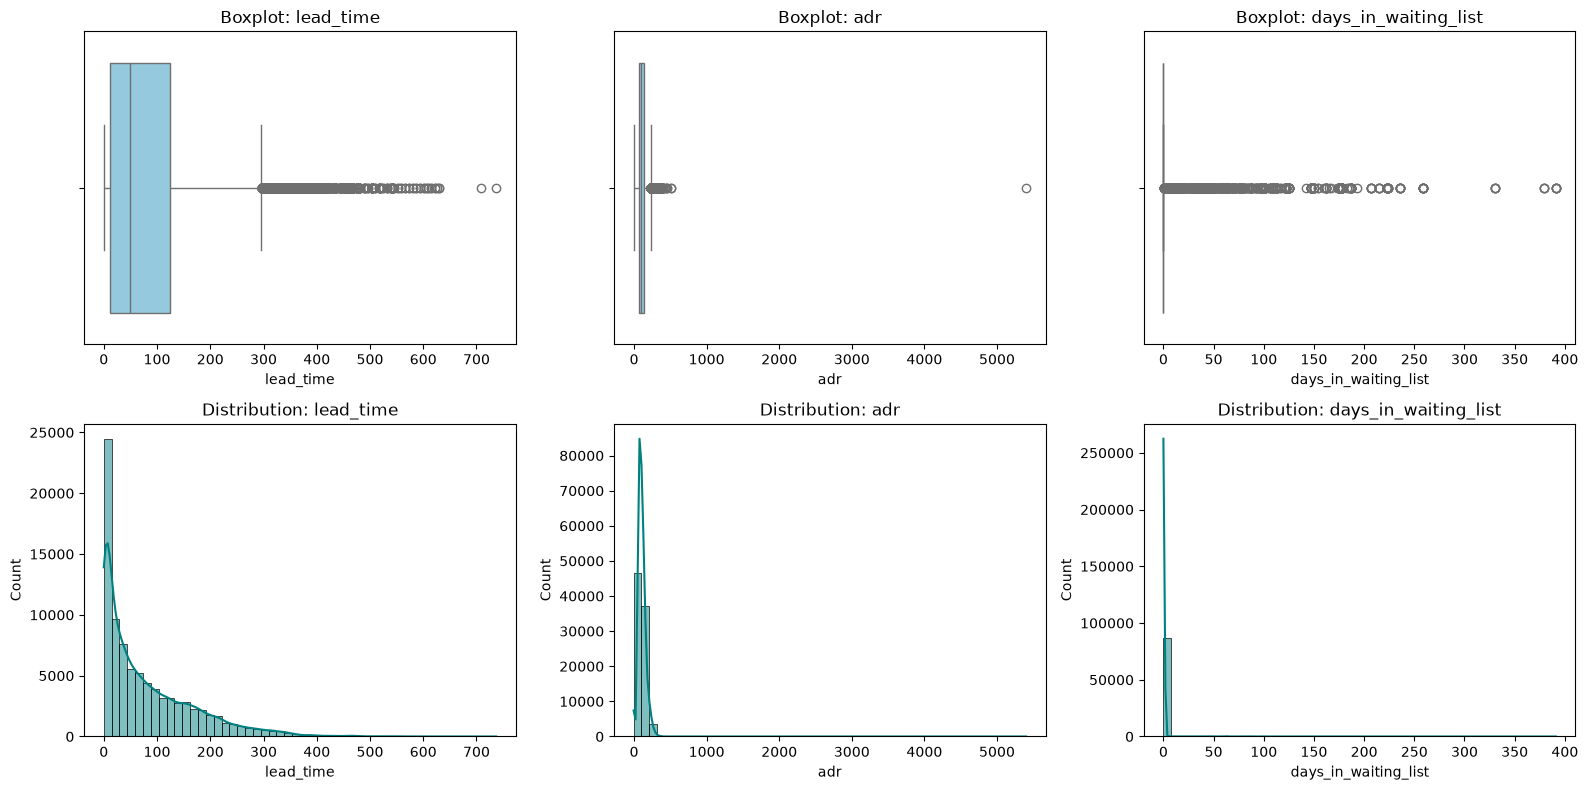

In [21]:
cols_to_plot = ['lead_time', 'adr', 'days_in_waiting_list']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(cols_to_plot):
    # 1. Boxplot 
    sns.boxplot(x=df[col], ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Boxplot: {col}')
    
    # 2. Histogram
    sns.histplot(df[col], bins=50, kde=True, ax=axes[1, i], color='teal')
    axes[1, i].set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()

leadtime we can see right skewness (yeo jhonson)
,adr has 1 outlier that squishing the whole scale down
waiting days is either 0 or skyrockets so i decided to binarize this

In [22]:
#from sklearn.preprocessing import PowerTransformer
#pt = PowerTransformer(method='yeo-johnson')

In [23]:
df_cleaned = df.copy()

df_cleaned = df_cleaned[(df_cleaned['adr'] > 0) & (df_cleaned['adr'] < 1000)]
df_cleaned['was_in_waiting_list'] = (df_cleaned['days_in_waiting_list'] > 0).astype(int)

here i made a new df named it df_cleaned and assigned the data after the cleaning (i didnt do any transformations yet cuz i am cleaning before the splitting of the data) #we can't perform transformations before splitting to prevent data leakage

/tmp/ipykernel_135917/1300859325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_cleaned['was_in_waiting_list'], ax=axes[0, 1], palette='Purples_r')
/tmp/ipykernel_135917/1300859325.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 1].set_xticklabels(['No Wait (0)', 'Had Wait (1)'])


[Text(0, 0, 'No Wait (0)'), Text(1, 0, 'Had Wait (1)')]

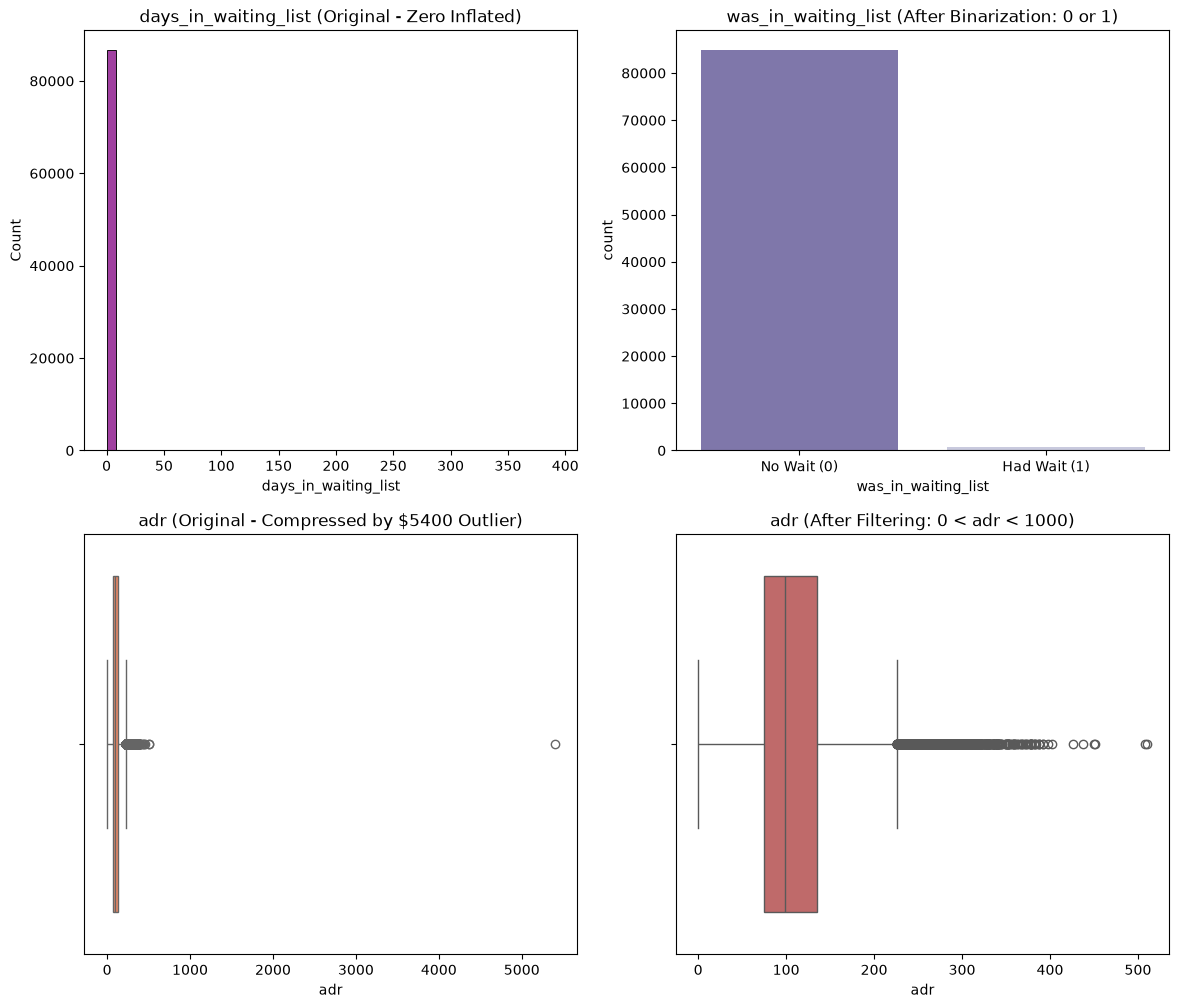

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.boxplot(x=df['adr'], ax=axes[1, 0], color='coral')
axes[1, 0].set_title('adr (Original - Compressed by $5400 Outlier)')

sns.boxplot(x=df_cleaned['adr'], ax=axes[1, 1], color='indianred')
axes[1, 1].set_title('adr (After Filtering: 0 < adr < 1000)')

sns.histplot(df['days_in_waiting_list'], bins=50, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('days_in_waiting_list (Original - Zero Inflated)')

sns.countplot(x=df_cleaned['was_in_waiting_list'], ax=axes[0, 1], palette='Purples_r')
axes[0, 1].set_title('was_in_waiting_list (After Binarization: 0 or 1)')
axes[0, 1].set_xticklabels(['No Wait (0)', 'Had Wait (1)'])

here is a visualization of the data after dropping the extreme value from adr and after binarizing the waiting list

<Axes: xlabel='adr', ylabel='Count'>

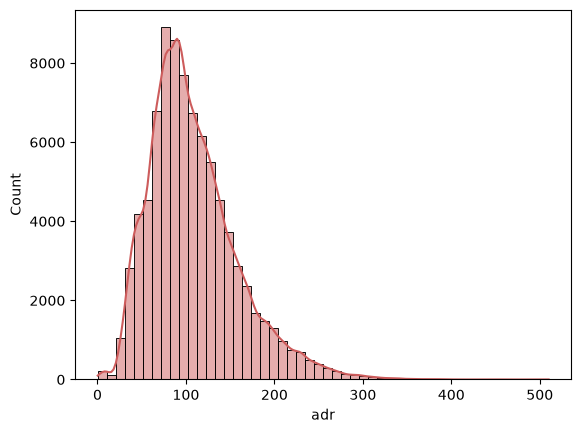

In [25]:
sns.histplot(df_cleaned['adr'], bins=50, kde=True, color='indianred')

here `adr` still has right skewness so again we will apply `yeo jhonson` to it as well as `leadtime` ( i promise i didnt use ai i know the ` trick)

/tmp/ipykernel_135917/261370367.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[1, i], palette='flare')
/tmp/ipykernel_135917/261370367.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[1, i], palette='flare')
/tmp/ipykernel_135917/261370367.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[1, i], palette='flare')


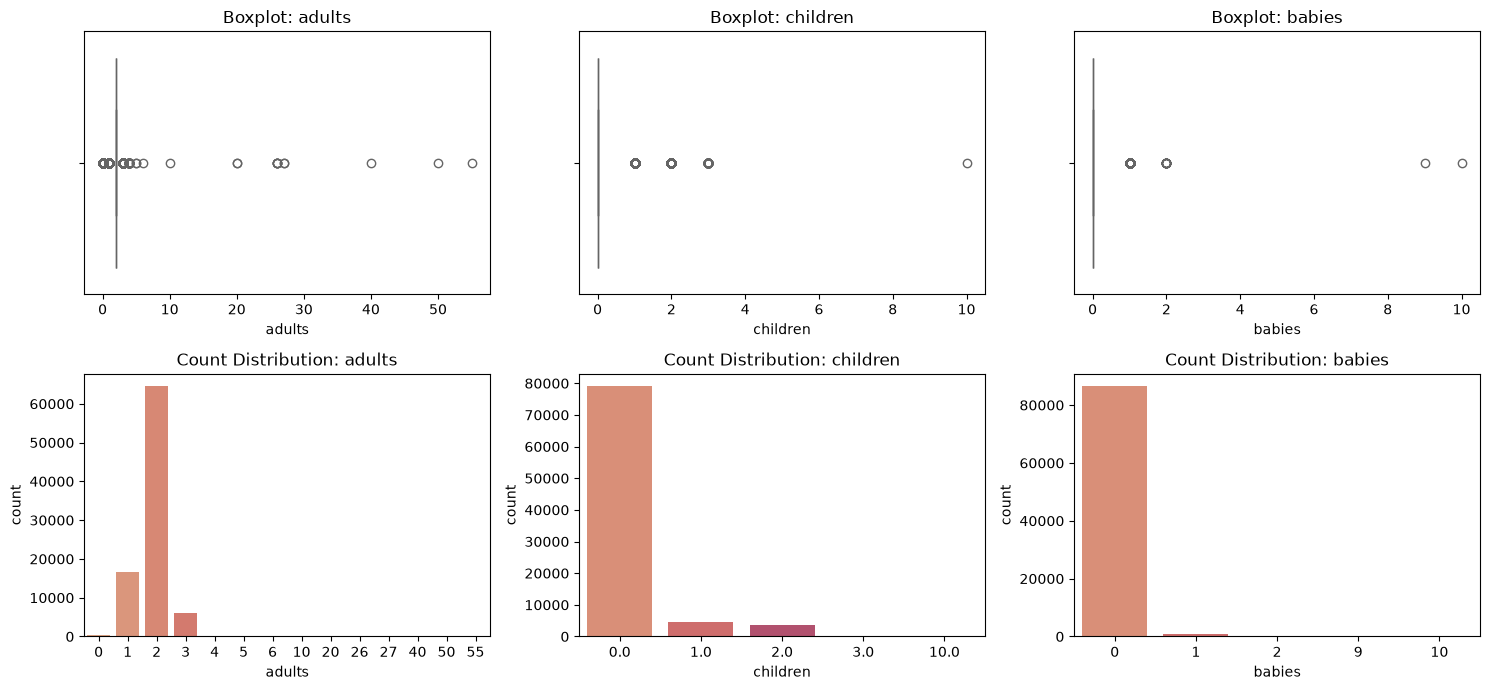

In [26]:
guest_cols = ['adults', 'children', 'babies']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, col in enumerate(guest_cols):
    # Boxplot 
    sns.boxplot(x=df[col], ax=axes[0, i], color='coral')
    axes[0, i].set_title(f'Boxplot: {col}')
    
    # Countplot (better than histplot for discrete integer counts)
    sns.countplot(x=df[col], ax=axes[1, i], palette='flare')
    axes[1, i].set_title(f'Count Distribution: {col}')

plt.tight_layout()
plt.show()

here since most adults lie from 0-4 i will drop values higher than 4
as well as children, as well as babies, its not even logical to have 10 children or 10 babies i 1 rooom and defo not 55 aduts in 1 room 100% a data entry error

In [27]:
df_cleaned = df_cleaned[df_cleaned['adults'] <= 4]
df_cleaned = df_cleaned[df_cleaned['children'] < 5]
df_cleaned = df_cleaned[df_cleaned['babies'] < 5]

zero_guests = df_cleaned[df_cleaned['adults'] + df_cleaned['children'] + df_cleaned['babies'] == 0]
print(f"Zero guest rows: {len(zero_guests)}")

Zero guest rows: 31


after dropping and checking for zero guest rows it is 31 (which we will drop cuz it makes no sense to have booked rooms with 0 guests) also the number 31 was 166 before cleaning, can be checked through normal df and not df_cleaned

In [28]:
df_cleaned = df_cleaned[df_cleaned['adults'] + df_cleaned['children'] + df_cleaned['babies'] > 0]

here i am checking if my data is cleaned (no null, no zero guests rows) 

In [29]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_cleaned.shape}")

print("\n--- Remaining Missing Values ---")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])


zero_guests = (df_cleaned['adults'] + df_cleaned['children'] + df_cleaned['babies'] == 0).sum()
print(f"\nZero-guest rows remaining: {zero_guests}")


Original shape: (87396, 34)
Cleaned shape:  (85582, 35)

--- Remaining Missing Values ---
agent      11303
company    80711
dtype: int64

Zero-guest rows remaining: 0


here i forgot to drop the original agent,company cols

In [30]:
df_cleaned = df_cleaned.drop(columns=['agent', 'company', 'days_in_waiting_list'])
print("Remaining Missing Values:")
print(df_cleaned.isnull().sum().sum())

Remaining Missing Values:
0


here i am checking my cols if they even exist

In [31]:
for col in ['has_agent', 'has_company', 'was_in_waiting_list']: 
    if col in df_cleaned.columns:
        print(f"--- {col} ---")
        print(df_cleaned[col].value_counts(dropna=False))
        print()

--- has_agent ---
has_agent
1    74279
0    11303
Name: count, dtype: int64

--- has_company ---
has_company
0    80711
1     4871
Name: count, dtype: int64

--- was_in_waiting_list ---
was_in_waiting_list
0    84748
1      834
Name: count, dtype: int64



now our data is ready for splitting

In [32]:
from sklearn.model_selection import train_test_split

X = df_cleaned.drop(columns=['is_canceled'])
y = df_cleaned['is_canceled']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

now apply yeo jhonson

In [33]:
from sklearn.preprocessing import PowerTransformer


pt = PowerTransformer(method='yeo-johnson')

cols_to_transform = ['lead_time', 'adr']

X_train[cols_to_transform] = pt.fit_transform(X_train[cols_to_transform])

X_test[cols_to_transform] = pt.transform(X_test[cols_to_transform])

we never fit the test to avoid data leakage and to avoid completely different scales

In [34]:
X_train[cols_to_transform].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
lead_time,-2.171117e-16,1.000007,-1.780648,2.761100
adr,1.382375e-16,1.000007,-4.949608,4.577455


encoding categorical cols

In [35]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

/tmp/ipykernel_135917/4032795961.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


we also scale them using standard scaler as to not break the gradient descent algorithim

In [36]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

/home/shawky/Documents/nti/actual nti/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3, 11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [37]:
X_train_ready = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_ready = pd.concat([X_test_num, X_test_cat], axis=1)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression()
model.fit(X_train_ready, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [39]:
y_pred = model.predict(X_test_ready)


In [40]:
model.score(X_test_ready, y_test)

1.0